In [1]:
import pandas as pd

import numpy as np

def safe_div(num, den):
    return (num / den).replace([np.inf, -np.inf], 0).fillna(0)

In [2]:
df_standard = pd.read_csv("standard.csv")
df_shooting = pd.read_csv("shooting.csv")
df_misc = pd.read_csv("misc.csv")


#limpar linhas repetidas
df_std_clean = df_standard[df_standard['Player'] != 'Player'].copy()
df_shoot_clean = df_shooting[df_shooting['Player'] != 'Player'].copy()
df_misc_clean = df_misc[df_misc['Player'] != 'Player'].copy()




colunas_standard = list(df_std_clean.columns)
contagem = {}
for i, col in enumerate(colunas_standard):
    if col in ['Gls', 'Ast', 'G+A', 'G-PK', 'G+A-PK']:
        contagem[col] = contagem.get(col, 0) + 1
        if contagem[col] == 2:  # É a versão "Per 90 Minutes"
            colunas_standard[i] = col + '_per90'
df_std_clean.columns = colunas_standard


cols_shoot_exclusivas = ['Player', 'Squad', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT']
cols_misc_exclusivas = ['Player', 'Squad', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'PKcon', 'OG']

df_shoot_filtrado = df_shoot_clean[cols_shoot_exclusivas]
df_misc_filtrado = df_misc_clean[cols_misc_exclusivas]



df_passo_1 = pd.merge(df_std_clean, df_shoot_filtrado, on=['Player', 'Squad'], how='left')
df_final = pd.merge(df_passo_1, df_misc_filtrado, on=['Player', 'Squad'], how='left')



if 'Rk\n▲' in df_final.columns:
    df_final = df_final.rename(columns={'Rk\n▲': 'Rk'})
if 'Matches' in df_final.columns:
    df_final = df_final.drop(columns=['Matches'], errors='ignore')



df_final['Min'] = df_final['Min'].astype(str).str.replace(',', '')
colunas_texto = ['Player', 'Nation', 'Pos', 'Squad']

for col in df_final.columns:
    if col not in colunas_texto:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)
        if (df_final[col] % 1 == 0).all():
            df_final[col] = df_final[col].astype(int)

print(list(df_final.columns))

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'PKcon', 'OG']


In [3]:
MIN_MINUTOS = 10  # equivale a 90s >= 5, ou seja ~450 minutos jogados
df_final = df_final[df_final["90s"] >= MIN_MINUTOS].copy()

In [4]:
#metricas:


golos_equipa = (
    df_final
    .groupby("Squad")["Gls"]
    .sum()
    .reset_index(name="Golos_Equipa")
)
df_final = df_final.merge(golos_equipa, on="Squad")

remates_equipa = (
    df_final
    .groupby("Squad")["Sh"]
    .sum()
    .reset_index(name="Remates_Equipa")
)
df_final = df_final.merge(remates_equipa, on="Squad")


df_final["%Golos_Equipa"] = (df_final["Gls"] / df_final["Golos_Equipa"] * 100)
df_final["%Remates_Equipa"] = (df_final["Sh"] / df_final["Remates_Equipa"] * 100)

df_final["%_G+A_Equipa"] = ((df_final["Gls"] + df_final["Ast"]) / df_final["Golos_Equipa"]) * 100

df_final["%_Pontaria"] = (df_final["SoT"] / df_final["Sh"] * 100).fillna(0)

df_final["Golos_por_Remate_Enquadrado"] = (df_final["Gls"] / df_final["SoT"]).fillna(0)

df_final["Golos_por_Remate"] = (df_final["Gls"] / df_final["Sh"]).fillna(0)

df_final["Indice_Conversao_Relativa_Equipa"] = (df_final["%Golos_Equipa"]/ df_final["%Remates_Equipa"]).fillna(0)

df_final["Remates/90"] = (df_final["Sh"] / df_final["90s"]).fillna(0)

df_final["G+A s/ Penáltis/90"] = ((df_final["G-PK"] + df_final["Ast"]) / df_final["90s"]).fillna(0)

df_final["Ast_por_Crz_%"] = safe_div(df_final["Ast"], df_final["Crs"]) * 100

df_final["Cruzamentos/90"] = (df_final["Crs"] / df_final["90s"]).fillna(0)

df_final["Ações_Defensivas/90"] = ((df_final["TklW"] + df_final["Int"]) / df_final["90s"]).fillna(0)

df_final["TklW_por_Falta"] = safe_div(df_final["TklW"], df_final["Fls"])

df_final["Faltas/90"] = (df_final["Fls"] / df_final["90s"]).fillna(0)

df_final["Cartões/90"] = ((df_final["CrdY"]+df_final["CrdR"])/df_final["90s"]).fillna(0)

df_final["Indice_Disciplinar"] = ((df_final["CrdY"]*1) + (df_final["CrdR"]*3)) / df_final["90s"]




In [5]:
pos_map = {
    "GK": "GK",
    "DF": "DEF",
    "MF": "MID",
    "FW": "FWD",
}


metricas_por_posicao = {
    "DEF": ["Ações_Defensivas/90", "TklW_por_Falta", "Cartões/90", "Cruzamentos/90"],
    "MID": ["G+A s/ Penáltis/90", "Ações_Defensivas/90", "%_Pontaria", "Ast_por_Crz_%"],
    "FWD": ["Remates/90", "Golos_por_Remate", "G+A s/ Penáltis/90", "Indice_Conversao_Relativa_Equipa","Ast_por_Crz_%"],
}

df_final["Pos_Principal"] = df_final["Pos"].str.split(",").str[0]
df_final["Grupo_Posicao"] = df_final["Pos_Principal"].map(pos_map)


In [6]:
outfield = df_final[
    (df_final["Grupo_Posicao"] != "GK") & (df_final["Grupo_Posicao"].notna())
].copy()

In [7]:
print(outfield["Grupo_Posicao"].value_counts(dropna=False))

Grupo_Posicao
MID    117
DEF    104
FWD     45
Name: count, dtype: int64


In [8]:
def zscore_por_grupo(df, coluna, grupo_col="Grupo_Posicao"):
    media = df.groupby(grupo_col)[coluna].transform("mean")
    desvio = df.groupby(grupo_col)[coluna].transform("std")
    return (df[coluna] - media) / desvio

In [9]:
for grupo, metricas in metricas_por_posicao.items():
    mask = outfield["Grupo_Posicao"] == grupo
    for m in metricas:
        outfield.loc[mask, f"{m}_z"] = zscore_por_grupo(outfield.loc[mask], m)

In [10]:
z_cols = [c for c in outfield.columns if c.endswith("_z")]
print(z_cols)
outfield[["Player", "Grupo_Posicao"] + z_cols].sample(10)

['Ações_Defensivas/90_z', 'TklW_por_Falta_z', 'Cartões/90_z', 'Cruzamentos/90_z', 'G+A s/ Penáltis/90_z', '%_Pontaria_z', 'Ast_por_Crz_%_z', 'Remates/90_z', 'Golos_por_Remate_z', 'Indice_Conversao_Relativa_Equipa_z']


,Player,Grupo_Posicao,Ações_Defensivas/90_z,TklW_por_Falta_z,Cartões/90_z,Cruzamentos/90_z,G+A s/ Penáltis/90_z,%_Pontaria_z,Ast_por_Crz_%_z,Remates/90_z,Golos_por_Remate_z,Indice_Conversao_Relativa_Equipa_z
212,Léo Santos,DEF,-0.801627,-1.036886,1.070589,-0.594881,NaN,NaN,NaN,NaN,NaN,NaN
125,João Carvalho,MID,-0.498058,NaN,NaN,NaN,1.994720,1.111463,0.228071,NaN,NaN,NaN
47,Bastien Meupiyou,DEF,-0.106342,0.067678,-0.312607,-0.690950,NaN,NaN,NaN,NaN,NaN,NaN
176,Amar Dedić,DEF,-0.500484,0.754013,0.488855,0.518449,NaN,NaN,NaN,NaN,NaN,NaN
256,Zaidu Sanusi,DEF,-0.346996,0.787438,-0.855336,0.968808,NaN,NaN,NaN,NaN,NaN,NaN
217,Pedro Bondo,DEF,-0.683839,0.370735,0.957646,1.118818,NaN,NaN,NaN,NaN,NaN,NaN
250,Rodrigo Mora,MID,-0.433347,NaN,NaN,NaN,-0.387425,-0.600339,-0.372820,NaN,NaN,NaN
161,Iván Fresneda,DEF,-0.393383,0.099578,0.552968,1.294666,NaN,NaN,NaN,NaN,NaN,NaN
25,Clayton,FWD,NaN,NaN,NaN,NaN,1.321343,NaN,0.945873,0.173073,0.925694,0.995515
23,Jalen Blesa,FWD,NaN,NaN,NaN,NaN,0.518168,NaN,-0.667649,-0.481585,1.691046,1.787762


In [11]:
pesos_por_posicao = {
    "DEF": {
        "Ações_Defensivas/90_z": 0.35,
        "TklW_por_Falta_z": 0.20,
        "Cruzamentos/90_z": 0.10,
        "Cartões/90_z": -0.25,
    },
    "MID": {
        "G+A s/ Penáltis/90_z": 0.25,
        "Ações_Defensivas/90_z": 0.25,
        "%_Pontaria_z": 0.20,
        "Ast_por_Crz_%_z": 0.15,
    },
    "FWD": {
        "Remates/90_z": 0.20,
        "Golos_por_Remate_z": 0.25,
        "G+A s/ Penáltis/90_z": 0.25,
        "Indice_Conversao_Relativa_Equipa_z": 0.15,
        "Ast_por_Crz_%_z": 0.15,
    },
}

In [12]:
outfield["rating_bruto"] = np.nan

for grupo, pesos in pesos_por_posicao.items():
    mask = outfield["Grupo_Posicao"] == grupo
    soma = pd.Series(0.0, index=outfield.loc[mask].index)
    for coluna_z, peso in pesos.items():
        soma += outfield.loc[mask, coluna_z].fillna(0) * peso
    outfield.loc[mask, "rating_bruto"] = soma

In [13]:
def reescala_0_100(serie):
    return 50 + 10 * (serie - serie.mean()) / serie.std()

outfield["rating"] = np.nan
for grupo in pesos_por_posicao:
    mask = outfield["Grupo_Posicao"] == grupo
    outfield.loc[mask, "rating"] = reescala_0_100(outfield.loc[mask, "rating_bruto"]).clip(0, 100)

outfield["rating"] = outfield["rating"].round(1)

In [14]:
for pos in ["DEF", "MID", "FWD"]:
    print(f"\n=== Top 10 — {pos} ===")
    print(outfield[outfield["Grupo_Posicao"] == pos].nlargest(10, "rating")[["Player", "Squad", "rating"]].to_string(index=False))


=== Top 10 — DEF ===
                 Player       Squad  rating
            Samuel Dahl     Benfica    74.2
                 Bebeto     Tondela    71.6
           Paulo Victor Santa Clara    70.0
Francisco Reis Ferreira     Estoril    68.5
                 Otávio     Estrela    68.5
           Tomás Araújo     Benfica    68.2
           Nelson Abbey     Rio Ave    68.0
      Rodrigo Conceição     Tondela    66.1
           Jakub Kiwior       Porto    65.8
           João Aurélio    Nacional    65.0

=== Top 10 — MID ===
                  Player          Squad  rating
Leandro Barreiro Martins        Benfica    78.5
         Pedro Gonçalves    Sporting CP    73.3
         Morten Hjulmand    Sporting CP    71.6
           Gabriel Veiga          Porto    70.2
            Andreas Ntoi        Rio Ave    69.5
   Guilherme Neiva Silva    AVS Futebol    69.2
           Ricardo Horta          Braga    68.9
        Gonçalo Nogueira Vit. Guimarães    68.1
           João Carvalho        Estoril 

In [15]:
metricas_cluster = [
    "Remates/90",
    "G+A s/ Penáltis/90",
        "Cruzamentos/90",
    "Ações_Defensivas/90",
    "%_Pontaria",
]

X = outfield[metricas_cluster].copy()
print(X.isna().sum())  

Remates/90             0
G+A s/ Penáltis/90     0
Cruzamentos/90         0
Ações_Defensivas/90    0
%_Pontaria             0
dtype: int64


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
!pip install matplotlib


[notice] A new release of pip is available: 23.3.1 -> 26.1.2
[notice] To update, run: C:\Users\diogo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


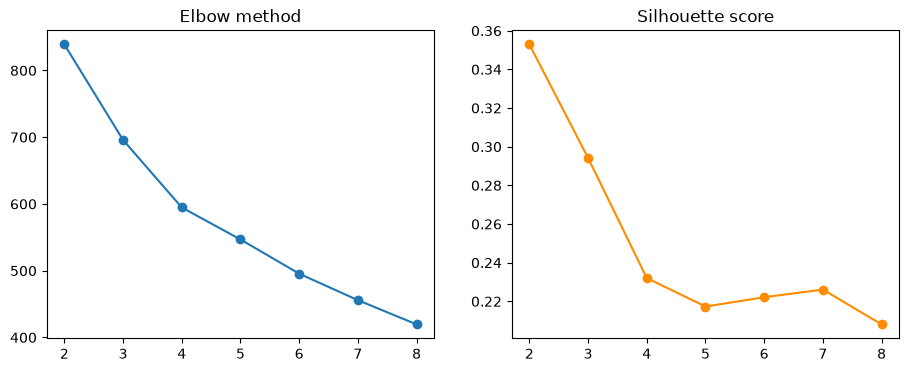

Melhor k por silhouette: 2


In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, sil_scores = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow method")
axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette score")
plt.show()

print("Melhor k por silhouette:", list(k_range)[int(pd.Series(sil_scores).idxmax())])

In [19]:
FINAL_K = 5
kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
outfield["cluster"] = kmeans.fit_predict(X_scaled)

print(outfield["cluster"].value_counts().sort_index())

cluster
0    53
1    35
2    51
3    79
4    48
Name: count, dtype: int64


In [20]:
perfil = outfield.groupby("cluster")[metricas_cluster].mean().round(2)
perfil["n_jogadores"] = outfield["cluster"].value_counts().sort_index()
print(perfil)

         Remates/90  G+A s/ Penáltis/90  Cruzamentos/90  Ações_Defensivas/90  \
cluster                                                                        
0              0.56                0.04            1.22                 2.24   
1              2.06                0.32            4.57                 1.37   
2              2.35                0.43            0.92                 0.82   
3              0.64                0.11            0.35                 2.15   
4              0.90                0.18            2.88                 2.21   

         %_Pontaria  n_jogadores  
cluster                           
0              8.53           53  
1             33.24           35  
2             42.42           51  
3             31.68           79  
4             35.59           48  


In [21]:
print(pd.crosstab(outfield["cluster"], outfield["Grupo_Posicao"]))

Grupo_Posicao  DEF  FWD  MID
cluster                     
0               34    0   19
1                0    7   28
2                0   37   14
3               46    0   33
4               24    1   23


In [22]:
for c in range(5):
    print(f"\n--- Cluster {c} ---")
    print(outfield[outfield["cluster"] == c][["Player", "Squad", "Grupo_Posicao"]].sample(5, random_state=1).to_string(index=False))


--- Cluster 0 ---
     Player          Squad Grupo_Posicao
  Zé Carlos Gil Vicente FC           DEF
João Mendes Vit. Guimarães           DEF
    Robinho        Estrela           MID
  Zé Carlos Gil Vicente FC           MID
  Zé Carlos Gil Vicente FC           DEF

--- Cluster 1 ---
             Player          Squad Grupo_Posicao
       Luís Esteves Gil Vicente FC           MID
Andreas Schjelderup        Benfica           MID
      Diogo Bezerra        Rio Ave           MID
               Pepê          Porto           FWD
     Abraham Marcus        Estrela           MID

--- Cluster 2 ---
         Player          Squad Grupo_Posicao
  Rafik Guitane        Estoril           MID
Nélson Oliveira Vit. Guimarães           FWD
          Kikas        Estrela           FWD
          Pablo Gil Vicente FC           FWD
     Rafa Silva        Benfica           MID

--- Cluster 3 ---
            Player      Squad Grupo_Posicao
      Taichi Fukui     Arouca           MID
      Kiko Bondoso Moreire

In [23]:
for c in [3, 4]:
    print(f"\n--- Cluster {c} ---")
    print(outfield[outfield["cluster"] == c][["Player", "Squad", "Grupo_Posicao"]].sample(5, random_state=1).to_string(index=False))


--- Cluster 3 ---
            Player      Squad Grupo_Posicao
      Taichi Fukui     Arouca           MID
      Kiko Bondoso Moreirense           MID
Mateja Stjepanović Moreirense           MID
     Pablo Rosario      Porto           MID
     António Silva    Benfica           DEF

--- Cluster 4 ---
          Player     Squad Grupo_Posicao
  Gabri Martínez     Braga           MID
  Ricard Sánchez   Estoril           DEF
      Gustavo sá Famalicão           MID
      Alan Núñez  Nacional           DEF
Brandon Aguilera   Rio Ave           MID


In [24]:
cluster_nomes = {
    0: "Defesas Puros",
    1: "Criadores pelos Corredores",
    2: "Finalizadores",
    3: "Contenção / Box-to-Box Defensivo",
    4: "Contribuição Larga (Cruzamento + Trabalho Defensivo)", 
}

outfield["estilo"] = outfield["cluster"].map(cluster_nomes)

In [25]:
!pip install seaborn


[notice] A new release of pip is available: 23.3.1 -> 26.1.2
[notice] To update, run: C:\Users\diogo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


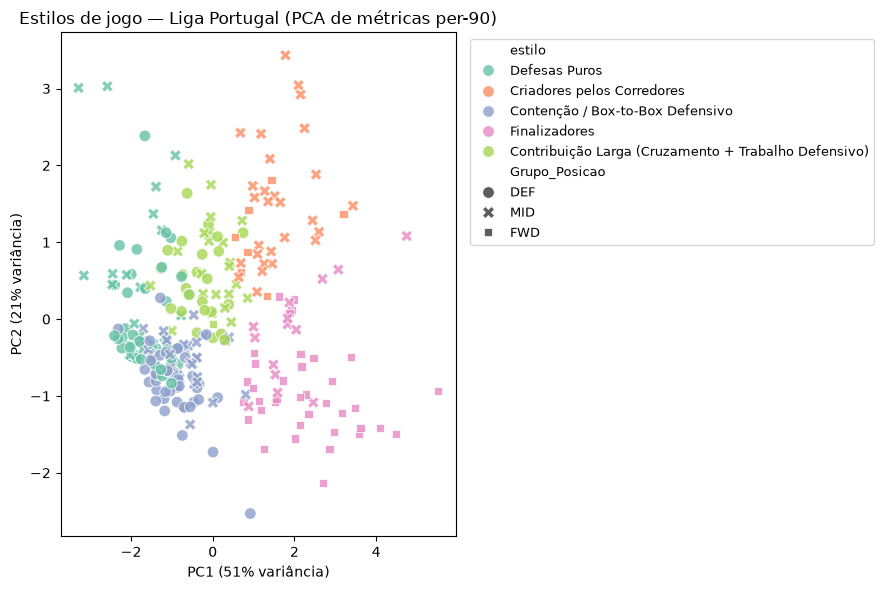

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
outfield["pca1"], outfield["pca2"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=outfield, x="pca1", y="pca2", hue="estilo",
                 style="Grupo_Posicao", s=70, alpha=0.8, palette="Set2")
plt.title("Estilos de jogo — Liga Portugal (PCA de métricas per-90)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variância)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variância)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
export_cols = [
    "Player",
    "Nation",
    "Age",
    "Squad",
    "Grupo_Posicao",
    "90s",

    "Gls",
    "Ast",
    "Sh",
    "SoT",
    "CrdY",
    "CrdR",

    "Golos_Equipa",
    "Remates_Equipa",

    "%Golos_Equipa",
    "%Remates_Equipa",
    "%_G+A_Equipa",

    "%_Pontaria",
    "Golos_por_Remate",
    "Golos_por_Remate_Enquadrado",
    "Indice_Conversao_Relativa_Equipa",  
    "Remates/90",
    "G+A s/ Penáltis/90",
    "Ast_por_Crz_%",
    "Cruzamentos/90",
    "Ações_Defensivas/90",
    "TklW_por_Falta",
    "Faltas/90",
    "Cartões/90",
    "Indice_Disciplinar",                
    "rating",
    "estilo"
]

final = outfield[export_cols]

In [28]:
final.to_csv("LigaPortugal_2025_2026.csv", index=False, encoding="utf-8-sig")
